In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
import pandas as pd
import numpy as np
import random
import pickle
import re
import base64

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics import r2_score
import seaborn as sns
# from ucimlrepo import fetch_ucirepo 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split

from data.data_loader import EPCDataset, PowerWeatherDatasetWithSeason, PowerWeatherDataset, SingleTermDataset, MultiTermDataset
from models.lstm import LSTMModel
from models.lstm_attention import LSTMWithAttention, BiLSTMWithAttention
from models.gru import GRUModel
from models.utils import create_model, train_for_short_term_forecast, train_for_long_term_forecast, load_model, evaluate_for_short_term_forecast, evaluate_for_long_term_forecast

from explainers.utils import get_explainer
# from explainers.lime import LimeExplainer
# from explainers.shap import ShapExplainer
# from explainers.attention import AttentionExplainer
# from explainers.grad_cam import GradCAMExplainer
# from explainers.lrp import LRPExplainer

In [2]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# short term 
features_for_1h = [
    'Global_active_power',
    'Global_intensity',
    'Sub_metering_1', 
    'Sub_metering_2', 
    'Sub_metering_3', 
    'Temperature',	
    'Humidity',	
]

# long term
features_for_6h = [
    'Global_active_power',
    'Global_intensity',
    'Sub_metering_1', 
    'Sub_metering_2', 
    'Sub_metering_3', 
    'Temp_Min',	'Temp_Max', 'Temp_Avg',	'Temp_Range',
    'Humidity_Min',	'Humidity_Max',	'Humidity_Avg',	'Humidity_Range'
]

file_path_for_1h = 'data/final_data.csv'
file_path_for_6h = 'data/final_data_per_6hr_with_avg_range.csv'

def load_dataset(params, target_features_long, target_features_short, is_long_term_forecast=True):
    selected_features = dict()
    
    if is_long_term_forecast:
        dataset_6h = EPCDataset(
            # file_path=file_path_for_6h,
            file_path=file_path_for_1h,
            sequence_length=params['long_term_length'],  
            prediction_length=params['long_term_pred_length'],
            target_features=target_features_long
        )
        train_long, train_targets_long, eval_long, eval_targets_long = dataset_6h.load_data()
        
        dataset_1h = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['short_term_length'],  
            prediction_length=params['short_term_pred_length'],
            target_features=target_features_short
        )
        train_short, train_targets_short, eval_short, eval_targets_short = dataset_1h.load_data()
        
        train_data=(train_long, train_short)
        train_targets=(train_targets_long, train_targets_short)
        eval_data=(eval_long, eval_short)
        eval_targets=(eval_targets_long, eval_targets_short)

        selected_features['long'] = dataset_6h.selected_features
        selected_features['short'] = dataset_1h.selected_features

    else:
        dataset_1h = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['sequence_length'],  
            prediction_length=params['prediction_length'],
            target_features=target_features_short
        )
        
        train_sequence, train_targets_sequence, eval_sequence, eval_targets_sequence = dataset_1h.load_data()

        train_data=train_sequence
        train_targets=train_targets_sequence
        eval_data=eval_sequence
        eval_targets=eval_targets_sequence
    
        selected_features['single'] = dataset_1h.selected_features

    return train_data, train_targets, eval_data, eval_targets, selected_features

In [4]:
dataset_params = {
    # for long-term forecast 

    # 'long_term_length' : 365*4, # 6시간 단위 1년 데이터
    'long_term_length' : 90*24,
    'long_term_pred_length' : 256, # 64, 128, 256
    
    'short_term_length' : 30*24, # 1시간 단위 한달 데이터
    'short_term_pred_length' : 7*24, # 일주일 데이터 예측

    
    # 2. LSTM, GRU, CNN-LSTM  -> 365*24 / 7*24 (비교용)
    # for Short-term forecast 
    'sequence_length' : 24*30,  # -> 일주일 / 10일 / 15일 / 한달  
    'prediction_length' : 24
}

is_long_term_forecast = False

In [5]:
train_data, train_targets, eval_data, eval_targets, selected_features = load_dataset(params=dataset_params,
                                                                                     target_features_long=features_for_1h, 
                                                                                     target_features_short=features_for_1h, 
                                                                                     is_long_term_forecast=is_long_term_forecast)

if isinstance(train_data, tuple):
    print("1-hour data sequences for long-term forecast:")
    print(f"  Train sequences shape: {train_data[0].shape}")
    print(f"  Train targets shape: {train_targets[0].shape}")
    print(f"  Eval sequences shape: {eval_data[0].shape}")
    print(f"  Eval targets shape: {eval_targets[0].shape}")
    print(f"  Selected_features: {selected_features['long']}")
    
    print("\n1-hour data sequences for long-term forecast:")
    print(f"  Train sequences shape: {train_data[1].shape}")
    print(f"  Train targets shape: {train_targets[1].shape}")
    print(f"  Eval sequences shape: {eval_data[1].shape}")
    print(f"  Eval targets shape: {eval_targets[1].shape}")
    print(f"  Selected_features: {selected_features['short']}")
    
else:
    print("1-hour data sequences for short-term forecast:")
    print(f"  Train sequences shape: {train_data.shape}")
    print(f"  Train targets shape: {train_targets.shape}")
    print(f"  Eval sequences shape: {eval_data.shape}")
    print(f"  Eval targets shape: {eval_targets.shape}")
    print(f"  Selected_features: {selected_features['single']}")

1-hour data sequences for short-term forecast:
  Train sequences shape: torch.Size([23925, 720, 13])
  Train targets shape: torch.Size([23925, 24])
  Eval sequences shape: torch.Size([5982, 720, 13])
  Eval targets shape: torch.Size([5982, 24])
  Selected_features: ['Global_active_power', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Temperature', 'Humidity', 'sin_hour', 'cos_hour', 'sin_day', 'cos_day', 'sin_month', 'cos_month']


In [6]:
def load_trained_model(params, selected_features):
    if params is None:
        return

    # Extract parameters
    model_name = params['model_name']
    hidden_size = params['hidden_size']
    num_layers = params['num_layers']
    dropout = params['dropout']
    num_epochs = params['num_epochs']
    batch_size = params['batch_size']
    learning_rate = params['learning_rate']
    patience = params['patience']
    mse_decay = params['mse_decay']

    if is_long_term_forecast == True:
        input_size = {
            'long': len(selected_features['long']),
            'short': len(selected_features['short']),
        }
        output_size = {
            'long': dataset_params['long_term_pred_length'],
            'short': dataset_params['short_term_pred_length'],
        }
    else:
        input_size = {
            'single': len(selected_features['single'])
        }
        output_size = {
            'single': dataset_params['prediction_length']
        }
        
    if mse_decay:
        mse_alpha = 0.3
        mse_beta = 1.0

    else:
        mse_alpha = 1.0
        mse_beta = 1.0

    # Model 생성 
    model = create_model(
        model_name=model_name,
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=output_size,
        dropout=dropout, 
        long_term_length=dataset_params['long_term_length'], 
        short_term_length=dataset_params['short_term_length']
    ) 

    if 'LS_CNNLSTM' in model_name:
        model_path = './trained_models/{}_long_{}_short_{}_{}_{}_{}_alpha_{}_beta_{}.pth'.format(
            model_name, dataset_params['long_term_length'], dataset_params['short_term_length'],
            dataset_params['long_term_pred_length'], hidden_size, num_layers, mse_alpha, mse_beta
        )
    else:
        model_path = './trained_models/{}_{}_{}_{}_{}.pth'.format(
            model_name, dataset_params['sequence_length'], dataset_params['prediction_length'],
             hidden_size, num_layers
        )
        
    print("Model path:", model_path)

    print(f"Loading the pre-trained {model_name} model...")
    model.load_state_dict(torch.load(model_path))
    model.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

    return model, model_path

In [7]:
model_params = {
    'model_name' : 'CNNLSTM', 
    'hidden_size' : 1024, # 256 # 512 # 1024
    'num_layers' : 3,  # 3
    'dropout' : 0.3,
    'num_epochs' : 200,
    'batch_size' : 16,
    'learning_rate' : 0.001,
    'patience' : 15,
    'mse_decay' : True   # 고정, 가중치 변화
}

model, model_path = load_trained_model(model_params, selected_features)

# print("Evaluating the model...")
# if is_long_term_forecast:
#     results = evaluate_for_long_term_forecast(
#         model=model,
#         eval_data=eval_data,
#         eval_targets=eval_targets,
#         model_name=model_params['model_name'],
#         batch_size=model_params['batch_size'], 
#         oversample_eval=True 
#     )
# else:
#     results = evaluate_for_short_term_forecast(
#         model=model,
#         eval_sequences=eval_data,
#         eval_targets=eval_targets,
#         model_name=model_params['model_name'],
#         batch_size=model_params['batch_size']
#     )

Model path: ./trained_models/CNNLSTM_720_24_1024_3.pth
Loading the pre-trained CNNLSTM model...


/tmp/ipykernel_1042508/3342642552.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


In [8]:
important_features_dict = {}


if isinstance(train_data, tuple):
    num_samples=len(eval_data[0])
else:
    num_samples=eval_data.shape[0]
    
num_samples=3500
print('num_samples: ', num_samples)


top_n=len(features_for_1h)

if is_long_term_forecast:
    sequence_length = {
        'long': dataset_params['long_term_length'],
        'short': dataset_params['short_term_length']
    }
    input_size = {
        # 'long': len(features_for_6h)+6,
        'long': len(features_for_1h)+6,
        'short': len(features_for_1h)+6,
        'single': len(features_for_1h)+6
    }
    output_size = {
        'long': dataset_params['long_term_pred_length'],
        'short': dataset_params['short_term_pred_length'],
        'single': dataset_params['prediction_length']
    }
else:
    sequence_length = {
        'single': dataset_params['sequence_length']
    }
    input_size = {
        'single': len(features_for_1h)+6
    }
    output_size = {
        'single': dataset_params['prediction_length']
    }

num_samples:  3500


In [9]:
explainer_type = 'LIME' 

explainer = get_explainer(
    explainer_type=explainer_type, 
    model=model, 
    device=device, 
    train_data=train_data,  
    sequence_length=sequence_length,
    input_size=input_size,
    selected_features=selected_features,
    scaler=MinMaxScaler()
)

is_long_term_forecast:  False
random_index:  4447


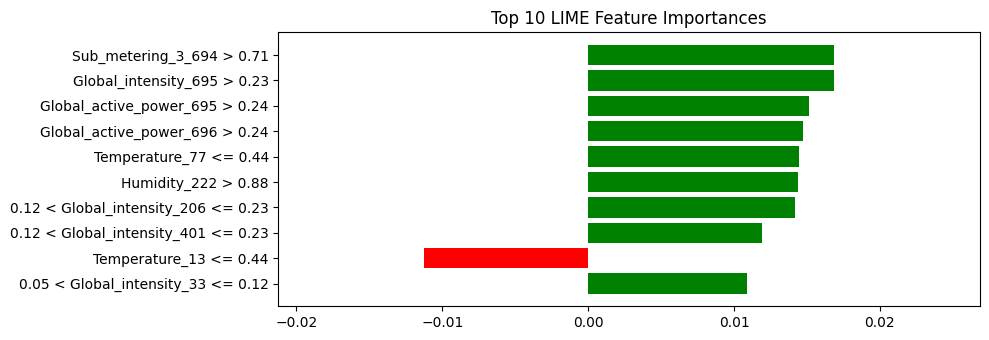

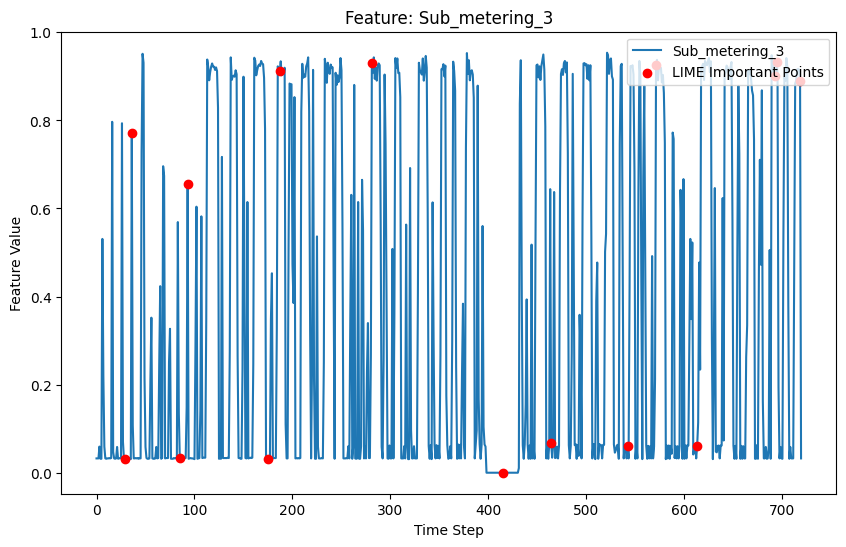


Feature: Sub_metering_3 - Detailed Information
Time Step: 694, Feature Value: 0.933, Importance: 0.017
Time Step: 692, Feature Value: 0.902, Importance: -0.011
Time Step: 93, Feature Value: 0.656, Importance: 0.010
Time Step: 281, Feature Value: 0.930, Importance: -0.008
Time Step: 718, Feature Value: 0.889, Importance: 0.008
Time Step: 464, Feature Value: 0.067, Importance: -0.008
Time Step: 415, Feature Value: 0.000, Importance: 0.007
Time Step: 187, Feature Value: 0.913, Importance: 0.006
Time Step: 29, Feature Value: 0.032, Importance: -0.006
Time Step: 175, Feature Value: 0.032, Importance: 0.006
Time Step: 36, Feature Value: 0.772, Importance: -0.005
Time Step: 571, Feature Value: 0.926, Importance: -0.005
Time Step: 85, Feature Value: 0.033, Importance: 0.003
Time Step: 613, Feature Value: 0.062, Importance: -0.003
Time Step: 542, Feature Value: 0.062, Importance: -0.002


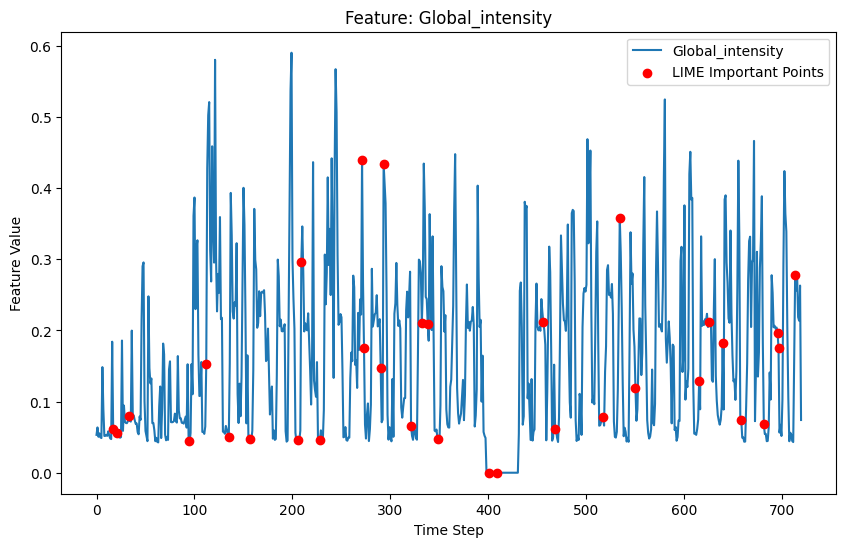


Feature: Global_intensity - Detailed Information
Time Step: 695, Feature Value: 0.197, Importance: 0.017
Time Step: 206, Feature Value: 0.045, Importance: 0.014
Time Step: 401, Feature Value: 0.000, Importance: 0.012
Time Step: 33, Feature Value: 0.079, Importance: 0.011
Time Step: 273, Feature Value: 0.175, Importance: -0.011
Time Step: 696, Feature Value: 0.175, Importance: 0.011
Time Step: 112, Feature Value: 0.152, Importance: 0.010
Time Step: 271, Feature Value: 0.440, Importance: 0.010
Time Step: 17, Feature Value: 0.062, Importance: 0.008
Time Step: 625, Feature Value: 0.212, Importance: -0.008
Time Step: 228, Feature Value: 0.047, Importance: 0.008
Time Step: 293, Feature Value: 0.434, Importance: 0.008
Time Step: 517, Feature Value: 0.078, Importance: -0.008
Time Step: 157, Feature Value: 0.047, Importance: 0.008
Time Step: 135, Feature Value: 0.050, Importance: 0.008
Time Step: 209, Feature Value: 0.296, Importance: 0.007
Time Step: 534, Feature Value: 0.358, Importance: 0.0

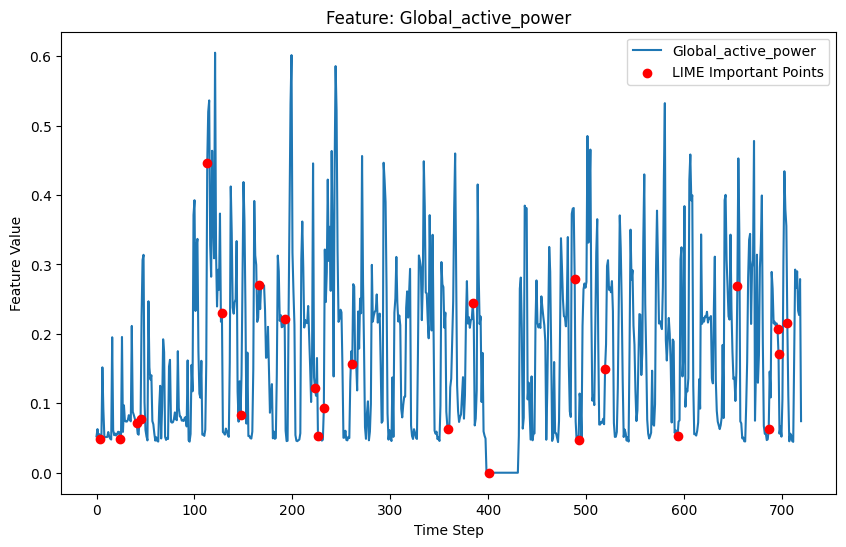


Feature: Global_active_power - Detailed Information
Time Step: 695, Feature Value: 0.208, Importance: 0.015
Time Step: 696, Feature Value: 0.171, Importance: 0.015
Time Step: 166, Feature Value: 0.271, Importance: 0.010
Time Step: 359, Feature Value: 0.063, Importance: -0.010
Time Step: 261, Feature Value: 0.156, Importance: 0.009
Time Step: 705, Feature Value: 0.216, Importance: 0.009
Time Step: 492, Feature Value: 0.048, Importance: -0.009
Time Step: 24, Feature Value: 0.048, Importance: -0.008
Time Step: 223, Feature Value: 0.122, Importance: 0.008
Time Step: 384, Feature Value: 0.244, Importance: -0.008
Time Step: 45, Feature Value: 0.077, Importance: -0.008
Time Step: 226, Feature Value: 0.053, Importance: -0.008
Time Step: 401, Feature Value: 0.000, Importance: 0.007
Time Step: 654, Feature Value: 0.268, Importance: -0.007
Time Step: 686, Feature Value: 0.063, Importance: -0.007
Time Step: 232, Feature Value: 0.093, Importance: 0.007
Time Step: 113, Feature Value: 0.446, Importa

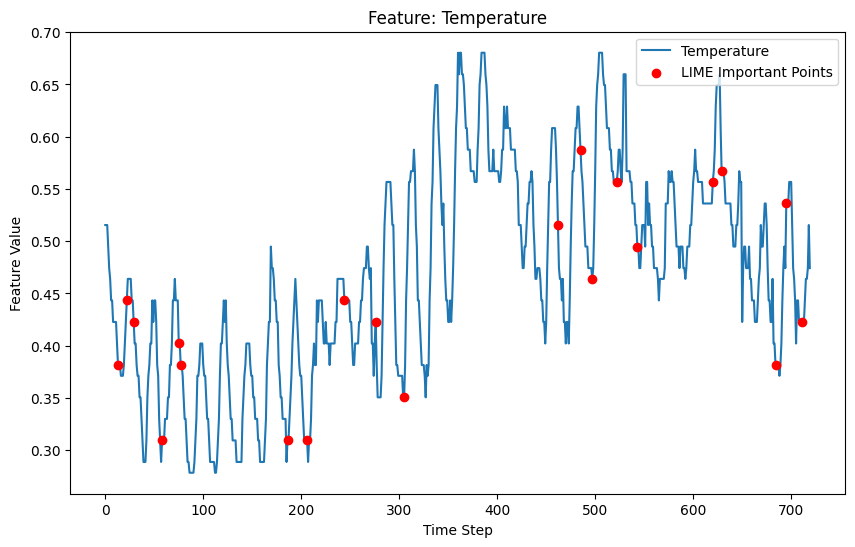


Feature: Temperature - Detailed Information
Time Step: 77, Feature Value: 0.381, Importance: 0.014
Time Step: 13, Feature Value: 0.381, Importance: -0.011
Time Step: 29, Feature Value: 0.423, Importance: -0.010
Time Step: 497, Feature Value: 0.464, Importance: 0.010
Time Step: 206, Feature Value: 0.309, Importance: 0.009
Time Step: 685, Feature Value: 0.381, Importance: 0.009
Time Step: 58, Feature Value: 0.309, Importance: -0.008
Time Step: 695, Feature Value: 0.536, Importance: 0.007
Time Step: 187, Feature Value: 0.309, Importance: 0.007
Time Step: 75, Feature Value: 0.402, Importance: -0.007
Time Step: 462, Feature Value: 0.515, Importance: 0.006
Time Step: 485, Feature Value: 0.588, Importance: 0.005
Time Step: 522, Feature Value: 0.557, Importance: 0.005
Time Step: 543, Feature Value: 0.495, Importance: 0.004
Time Step: 711, Feature Value: 0.423, Importance: -0.004
Time Step: 305, Feature Value: 0.351, Importance: 0.003
Time Step: 629, Feature Value: 0.567, Importance: -0.003
Ti

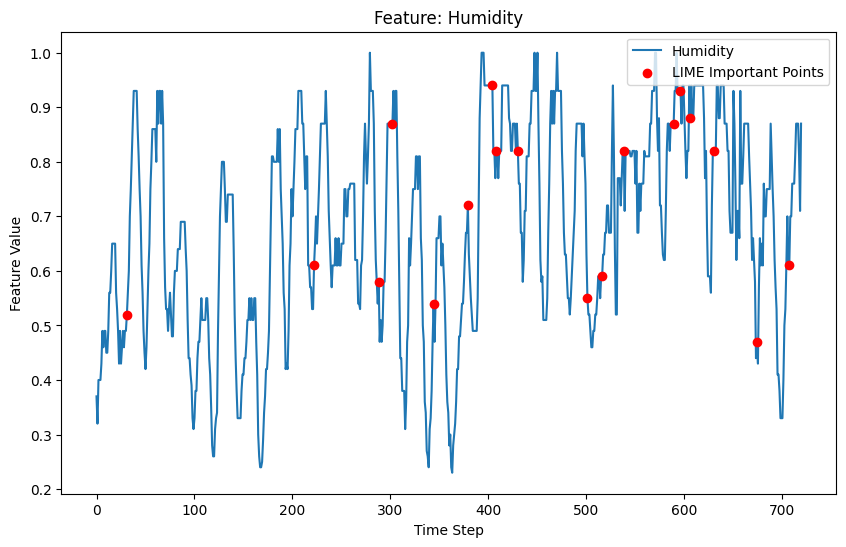


Feature: Humidity - Detailed Information
Time Step: 222, Feature Value: 0.610, Importance: 0.014
Time Step: 288, Feature Value: 0.580, Importance: -0.010
Time Step: 501, Feature Value: 0.550, Importance: -0.008
Time Step: 674, Feature Value: 0.470, Importance: 0.008
Time Step: 31, Feature Value: 0.520, Importance: 0.008
Time Step: 595, Feature Value: 0.930, Importance: 0.008
Time Step: 589, Feature Value: 0.870, Importance: 0.008
Time Step: 630, Feature Value: 0.820, Importance: 0.007
Time Step: 707, Feature Value: 0.610, Importance: 0.007
Time Step: 408, Feature Value: 0.820, Importance: -0.005
Time Step: 379, Feature Value: 0.720, Importance: 0.005
Time Step: 538, Feature Value: 0.820, Importance: 0.005
Time Step: 516, Feature Value: 0.590, Importance: -0.005
Time Step: 606, Feature Value: 0.880, Importance: -0.004
Time Step: 404, Feature Value: 0.940, Importance: -0.004
Time Step: 302, Feature Value: 0.870, Importance: 0.004
Time Step: 430, Feature Value: 0.820, Importance: -0.003


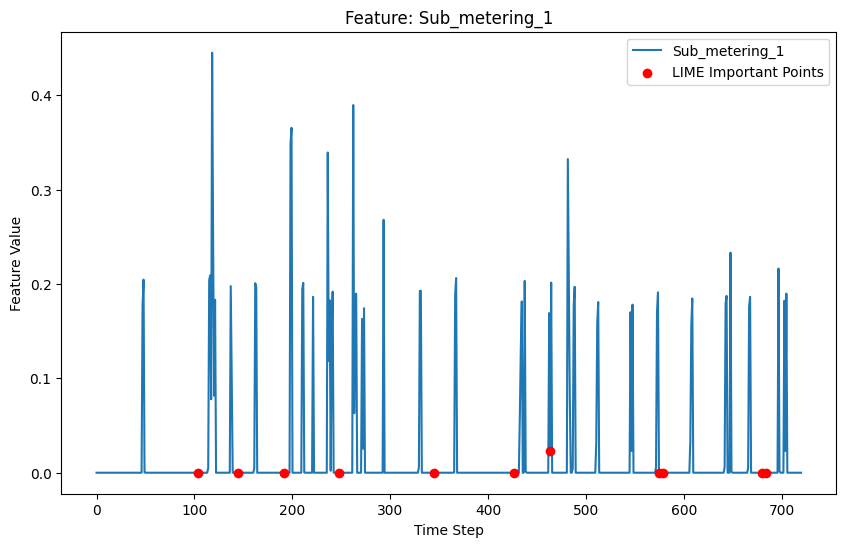


Feature: Sub_metering_1 - Detailed Information
Time Step: 144, Feature Value: 0.000, Importance: 0.010
Time Step: 463, Feature Value: 0.023, Importance: 0.010
Time Step: 578, Feature Value: 0.000, Importance: -0.009
Time Step: 574, Feature Value: 0.000, Importance: 0.009
Time Step: 104, Feature Value: 0.000, Importance: -0.008
Time Step: 344, Feature Value: 0.000, Importance: 0.007
Time Step: 679, Feature Value: 0.000, Importance: -0.007
Time Step: 247, Feature Value: 0.000, Importance: 0.006
Time Step: 426, Feature Value: 0.000, Importance: 0.005
Time Step: 683, Feature Value: 0.000, Importance: 0.005
Time Step: 191, Feature Value: 0.000, Importance: -0.002


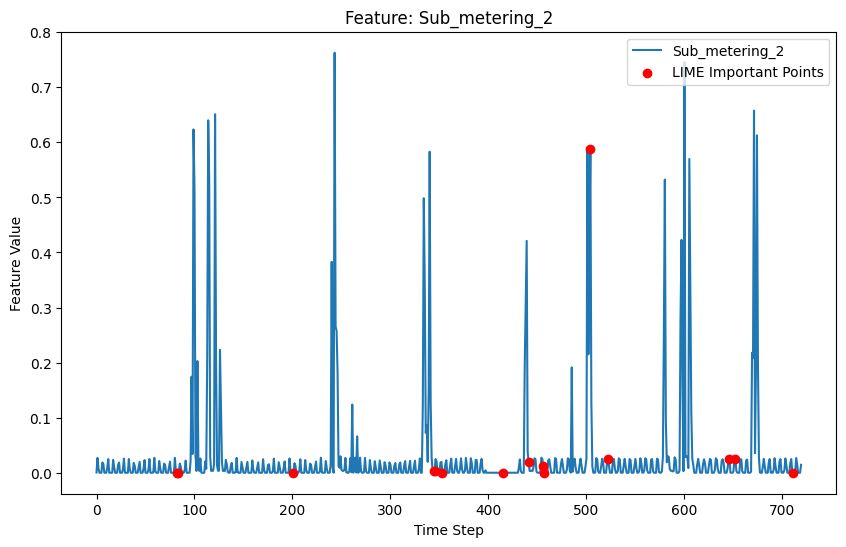


Feature: Sub_metering_2 - Detailed Information
Time Step: 645, Feature Value: 0.025, Importance: -0.010
Time Step: 652, Feature Value: 0.024, Importance: -0.009
Time Step: 353, Feature Value: 0.000, Importance: 0.009
Time Step: 457, Feature Value: 0.000, Importance: -0.008
Time Step: 82, Feature Value: 0.000, Importance: -0.008
Time Step: 345, Feature Value: 0.003, Importance: 0.007
Time Step: 504, Feature Value: 0.588, Importance: -0.007
Time Step: 711, Feature Value: 0.000, Importance: 0.006
Time Step: 83, Feature Value: 0.000, Importance: 0.006
Time Step: 415, Feature Value: 0.000, Importance: -0.005
Time Step: 522, Feature Value: 0.025, Importance: -0.005
Time Step: 456, Feature Value: 0.011, Importance: -0.005
Time Step: 344, Feature Value: 0.004, Importance: 0.004
Time Step: 441, Feature Value: 0.020, Importance: 0.003
Time Step: 201, Feature Value: 0.000, Importance: -0.002


In [10]:
print('is_long_term_forecast: ', is_long_term_forecast)


###인스턴스 하나 시각화

if is_long_term_forecast:
    random_index = np.random.choice(len(eval_data[0])) 
    print('random_index: ', random_index)
    
    random_data_point_long = eval_data[0][random_index]  # Long-term 데이터 포인트
    random_data_point_short = eval_data[1][random_index]  # Short-term 데이터 포인트
    
    data_point_long = random_data_point_long.cpu().numpy() if isinstance(random_data_point_long, torch.Tensor) else random_data_point_long
    data_point_short = random_data_point_short.cpu().numpy() if isinstance(random_data_point_short, torch.Tensor) else random_data_point_short
    
    print(data_point_long.shape)
    print(data_point_short.shape)
    
    # num_samples = num_samples-500 # -500: for attention model
    
    explanation = explainer.explain(
        data_point_long=data_point_long,
        data_point_short=data_point_short,
        eval_long=eval_data[0],
        eval_short=eval_data[1],
        # data_index=random_index,
        # num_features=top_n, 
        num_samples=num_samples,
        is_visual=True
    )

else:
    random_index = np.random.choice(len(eval_data)) 
    print('random_index: ', random_index)
    
    random_data_point = eval_data[random_index]  
    data_point = random_data_point.cpu().numpy() if isinstance(random_data_point, torch.Tensor) else random_data_point
    
    num_samples = num_samples - 500  # Attention 모델 대비 감소
    
    explanation = explainer.explain(
        data_point=data_point,
        eval_sequences=eval_data,
        num_samples=num_samples,
        is_visual=True
    )